In [1]:
!pip install kaggle shap lime xgboost --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [4]:
import os

# This shows you exactly what files are available
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/home-credit-default-risk/sample_submission.csv
/kaggle/input/competitions/home-credit-default-risk/bureau_balance.csv
/kaggle/input/competitions/home-credit-default-risk/POS_CASH_balance.csv
/kaggle/input/competitions/home-credit-default-risk/application_train.csv
/kaggle/input/competitions/home-credit-default-risk/HomeCredit_columns_description.csv
/kaggle/input/competitions/home-credit-default-risk/application_test.csv
/kaggle/input/competitions/home-credit-default-risk/previous_application.csv
/kaggle/input/competitions/home-credit-default-risk/credit_card_balance.csv
/kaggle/input/competitions/home-credit-default-risk/installments_payments.csv
/kaggle/input/competitions/home-credit-default-risk/bureau.csv


In [7]:
df = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/application_train.csv')
print("Shape:", df.shape)
df.head()

Shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
print("=== Dataset Info ===")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"\n=== Target Distribution ===")
print(df['TARGET'].value_counts())
print(f"\nDefault Rate: {df['TARGET'].mean()*100:.2f}%")

=== Dataset Info ===
Rows: 307511
Columns: 122

=== Target Distribution ===
TARGET
0    282686
1     24825
Name: count, dtype: int64

Default Rate: 8.07%


In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("Top 20 columns with missing values:")
missing_df[missing_df['Missing %'] > 0].head(20)

Top 20 columns with missing values:


,Missing Count,Missing %
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


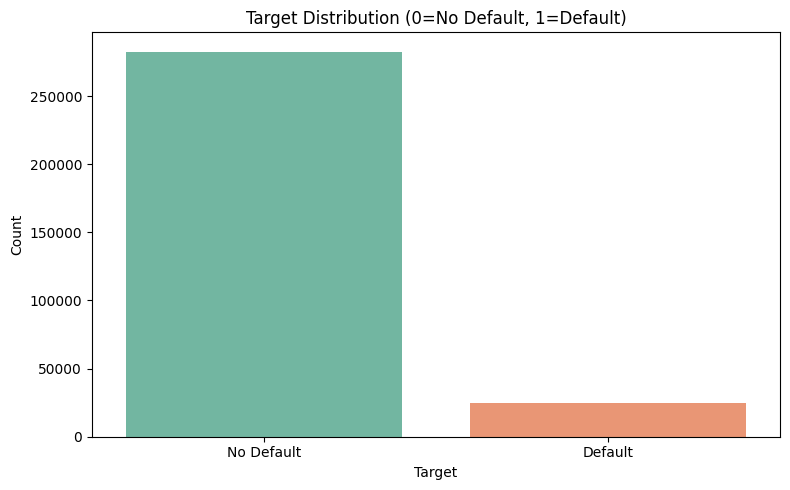

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(x='TARGET', data=df, palette='Set2')
plt.title('Target Distribution (0=No Default, 1=Default)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.xticks([0,1], ['No Default', 'Default'])
plt.tight_layout()
plt.show()

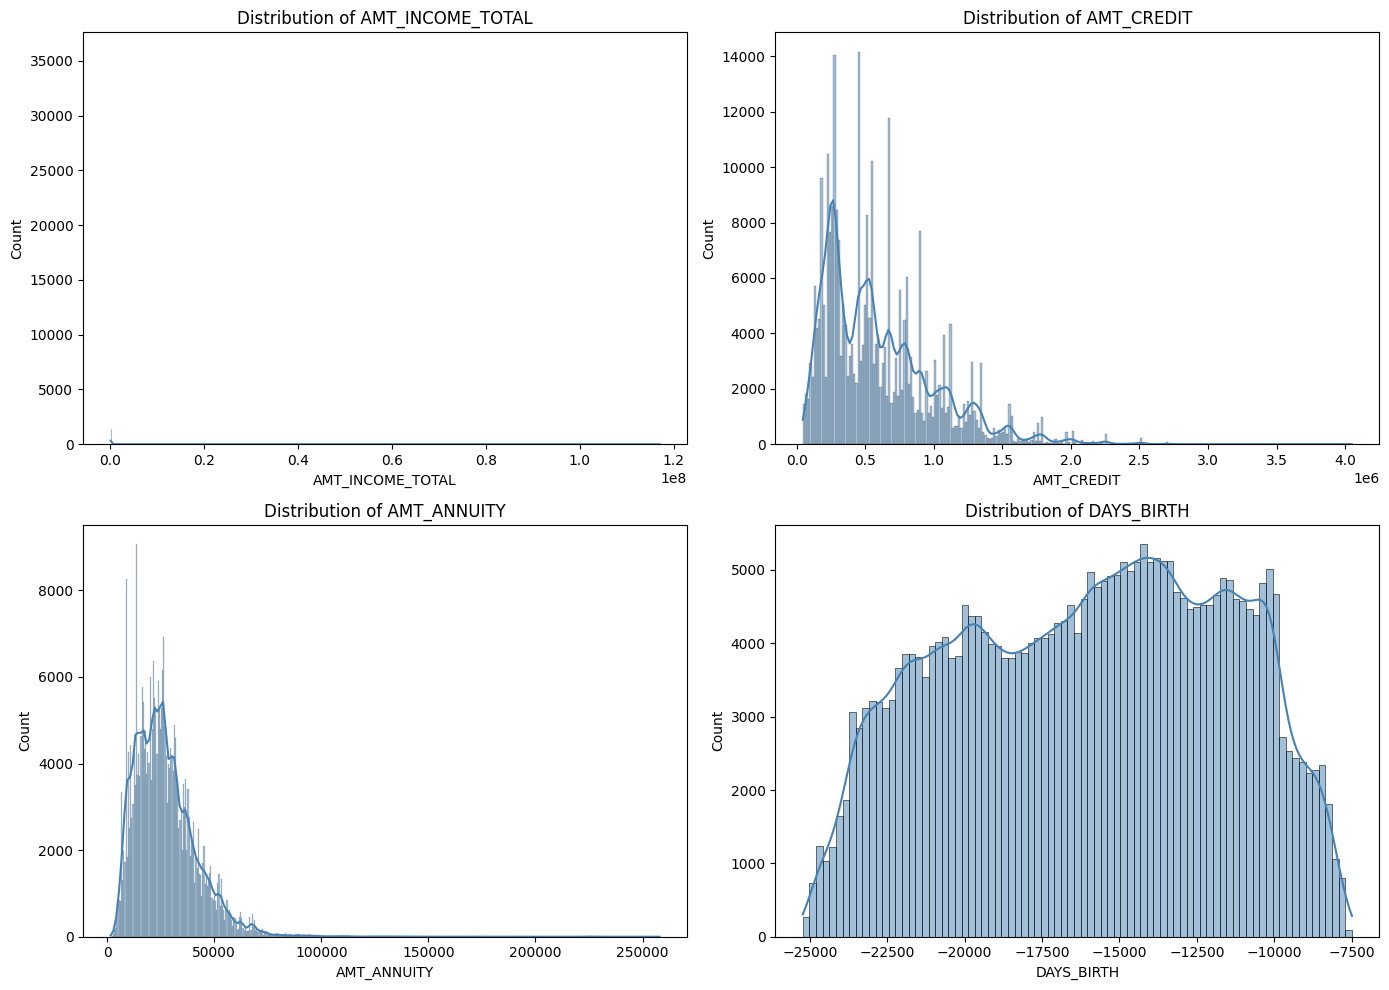

In [11]:
num_features = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(df[col], ax=axes[i], kde=True, color='steelblue')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

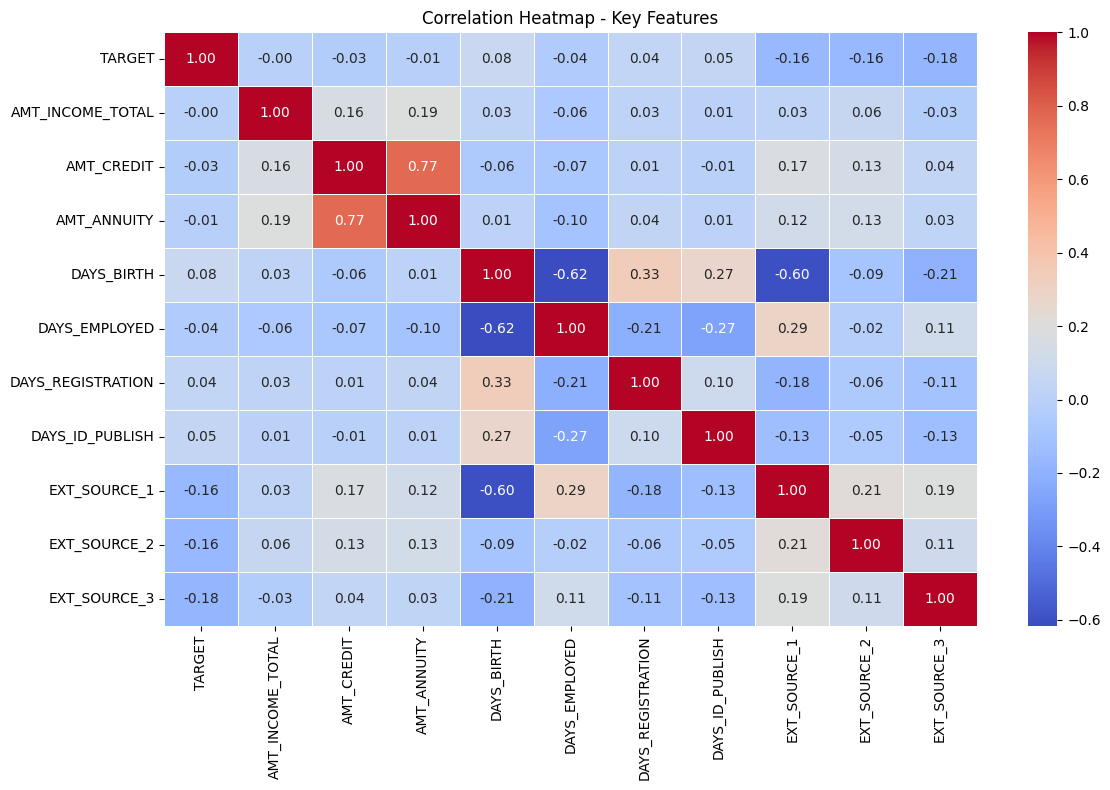

In [12]:
# Select top numerical columns
top_cols = ['TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
            'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
            'DAYS_ID_PUBLISH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

plt.figure(figsize=(12, 8))
sns.heatmap(df[top_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap - Key Features')
plt.tight_layout()
plt.show()

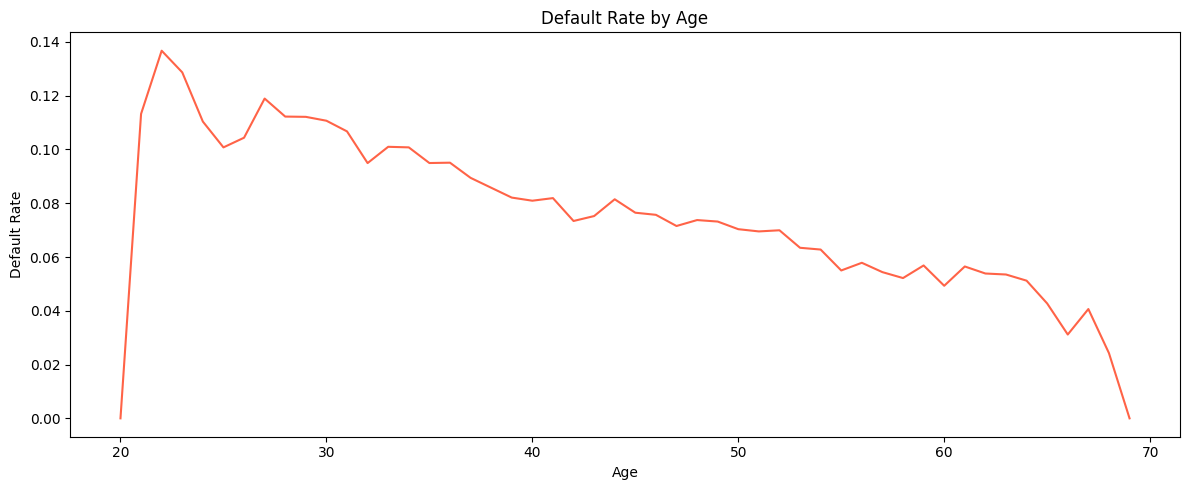

In [13]:
# Age vs Default Rate
df['AGE'] = (-df['DAYS_BIRTH'] / 365).astype(int)
age_default = df.groupby('AGE')['TARGET'].mean()

plt.figure(figsize=(12, 5))
age_default.plot(kind='line', color='tomato')
plt.title('Default Rate by Age')
plt.xlabel('Age')
plt.ylabel('Default Rate')
plt.tight_layout()
plt.show()

In [14]:
print("=== EDA Summary ===")
print(f"Total Records: {df.shape[0]:,}")
print(f"Total Features: {df.shape[1]}")
print(f"Default Rate: {df['TARGET'].mean()*100:.2f}%")
print(f"Missing Value Columns: {(df.isnull().sum()>0).sum()}")
print(f"Numeric Features: {df.select_dtypes(include=np.number).shape[1]}")
print(f"Categorical Features: {df.select_dtypes(include='object').shape[1]}")
print("\nEDA Complete! ✅")

=== EDA Summary ===
Total Records: 307,511
Total Features: 123
Default Rate: 8.07%
Missing Value Columns: 67
Numeric Features: 107
Categorical Features: 16

EDA Complete! ✅
